In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_excel(r"C:\Users\XPRISTO\Desktop\Data_anlisys\Online_Retail.xlsx")

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
data=data.drop(columns=['CustomerID'])
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom


drop customerID becouse he have many null vallu 

In [10]:
data=data.dropna(subset=['Description'])
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
Country        0
dtype: int64

delete all null rows in Description

In [11]:
data =data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

delete all dublicates 

In [12]:
print((data['Quantity'] <= 0).sum())
print((data['UnitPrice'] <= 0).sum())
data = data[data['UnitPrice'] > 0]

9725
1058


delete the rows that have a unitprice <= 0 

In [13]:
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
total_revenue = data['TotalPrice'].sum()

print(total_revenue)

9748131.074


add new colunm 'TotalPrice' and calculate the total revenue 

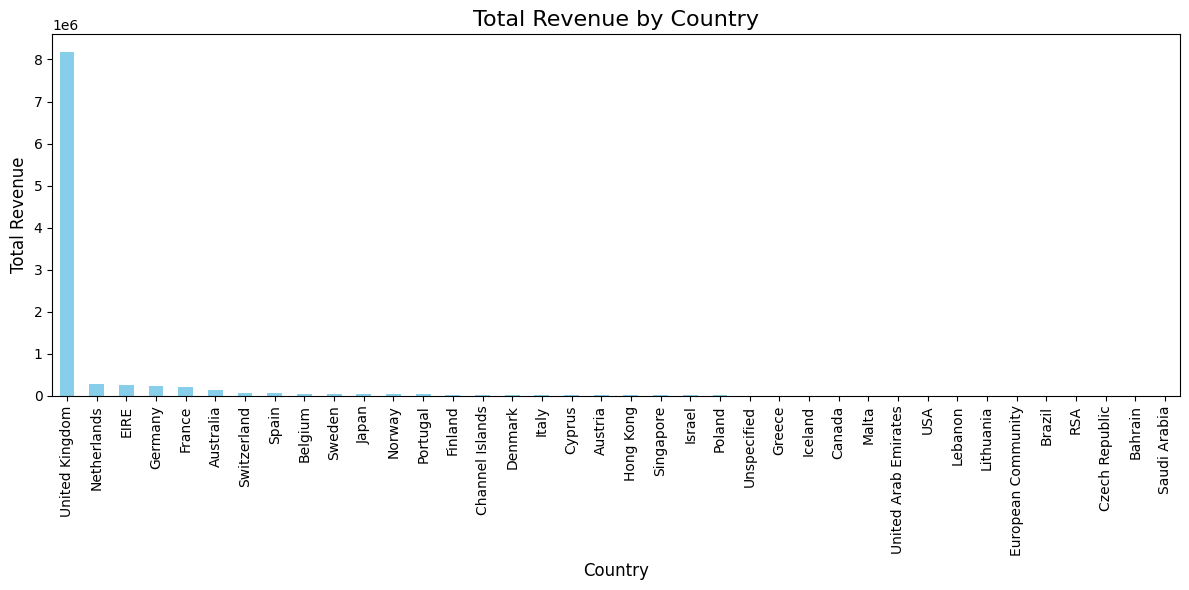

In [14]:
# Group data by country and calculate total revenue for each country
country_revenue = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
country_revenue.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

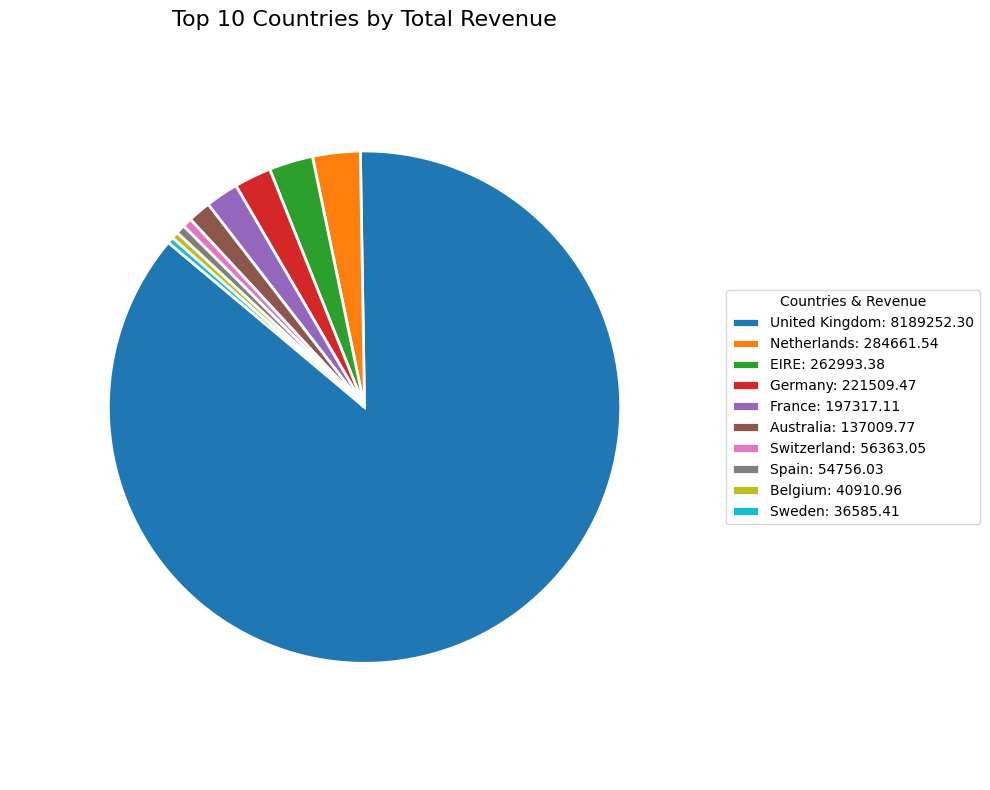

In [15]:
# Group data by country and calculate total revenue
country_revenue = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# ناخد أعلى 10 دول
top_10_countries = country_revenue.head(10)

# نجهز الأسامي بالشكل: (الدولة: الإيراد)
labels = [f"{country}: {revenue:.2f}" for country, revenue in zip(top_10_countries.index, top_10_countries.values)]

# رسم الدايرة
plt.figure(figsize=(10, 8))
plt.pie(top_10_countries, labels=None, startangle=140, wedgeprops={'linewidth': 2, 'edgecolor': 'white'})

# نحط الليجند بالأسامي + الإيرادات
plt.legend(labels, title="Countries & Revenue", loc="center left", bbox_to_anchor=(1, 0.5))

plt.title('Top 10 Countries by Total Revenue', fontsize=16)
plt.axis('equal')  # علشان الرسمة تبقى دايرة مظبوطة
plt.tight_layout()
plt.show()


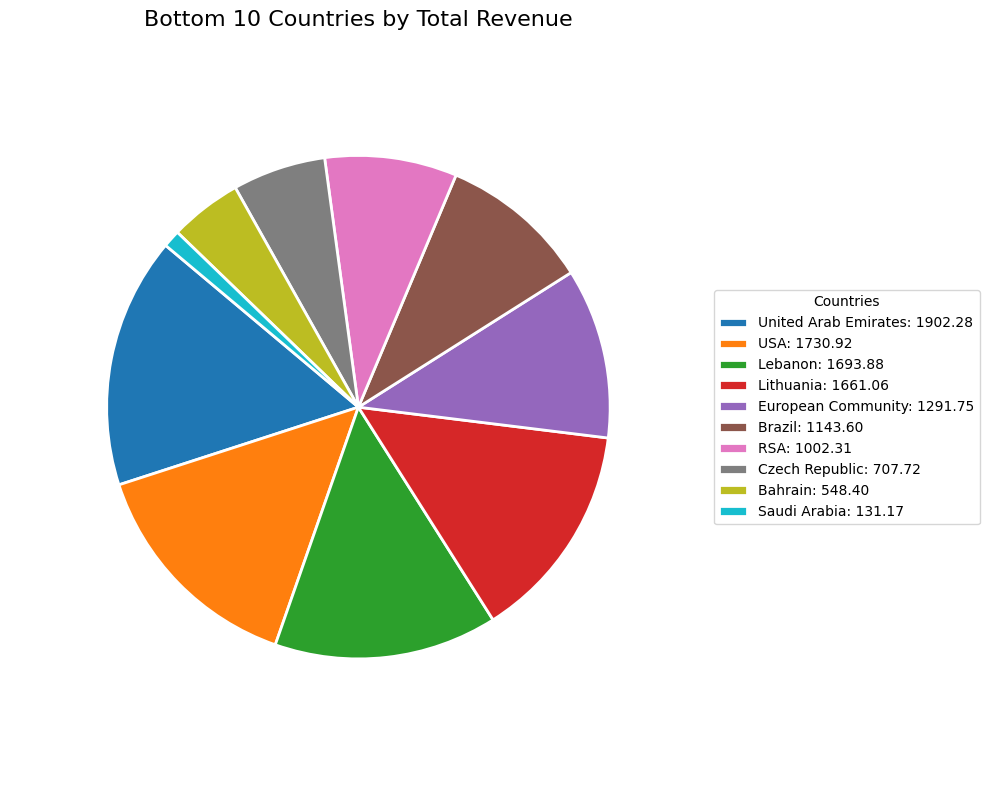

In [16]:
# Group data by country and calculate total revenue
country_revenue = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# ناخد أقل 10 دول
bottom_10_countries = country_revenue.tail(10)

# نجهز الأسامي مع الإيرادات
labels = [f"{country}: {revenue:.2f}" for country, revenue in zip(bottom_10_countries.index, bottom_10_countries.values)]

# رسم الدايرة
plt.figure(figsize=(10, 8))
plt.pie(bottom_10_countries, labels=None, startangle=140, wedgeprops={'linewidth': 2, 'edgecolor': 'white'})

# نعرض الليجند بالأسامي + الإيرادات
plt.legend(labels, title="Countries", loc="center left", bbox_to_anchor=(1, 0.5))

plt.title('Bottom 10 Countries by Total Revenue', fontsize=16)
plt.axis('equal')  # علشان الدايرة تطلع مظبوطة
plt.tight_layout()
plt.show()

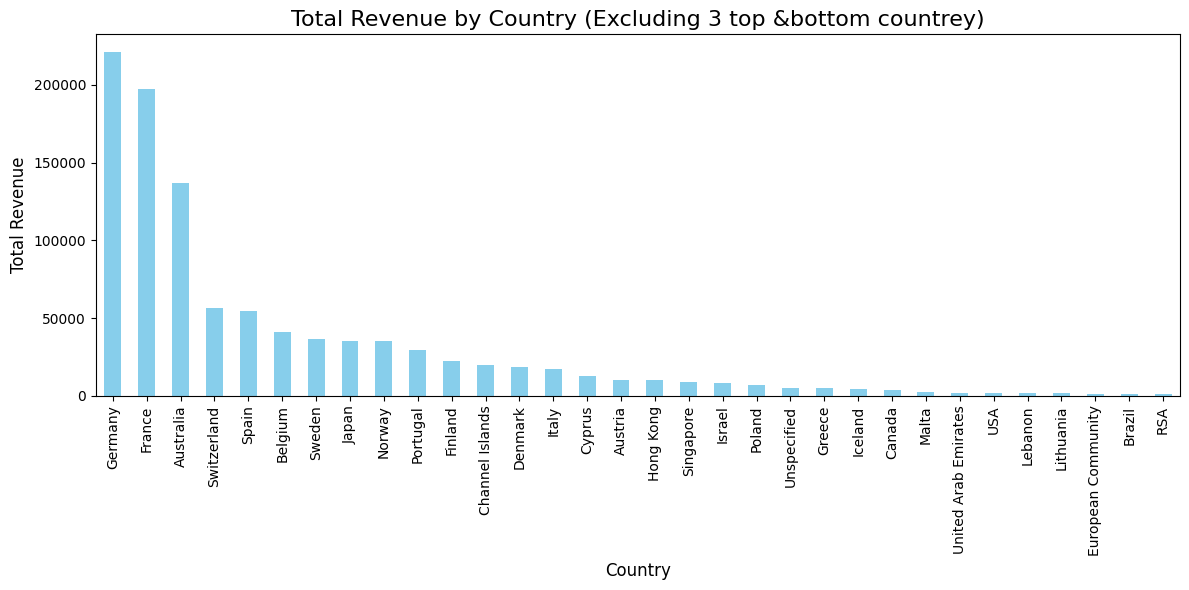

In [17]:
filtered_country_revenue = country_revenue.drop(['United Kingdom','Netherlands','EIRE','Saudi Arabia','Bahrain','Czech Republic'])

# Plot the bar chart
plt.figure(figsize=(12, 6))
filtered_country_revenue.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Country (Excluding 3 top &bottom countrey)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [18]:
sales_data = data[data['Quantity'] > 0].copy()   # المبيعات
returns_data = data[data['Quantity'] < 0].copy() # المرتجعات
returns_data['Quantity'] = returns_data['Quantity'].abs() 

Splitting data into two parts(sales ,returnes ) and make the returns positev to be esey in work 

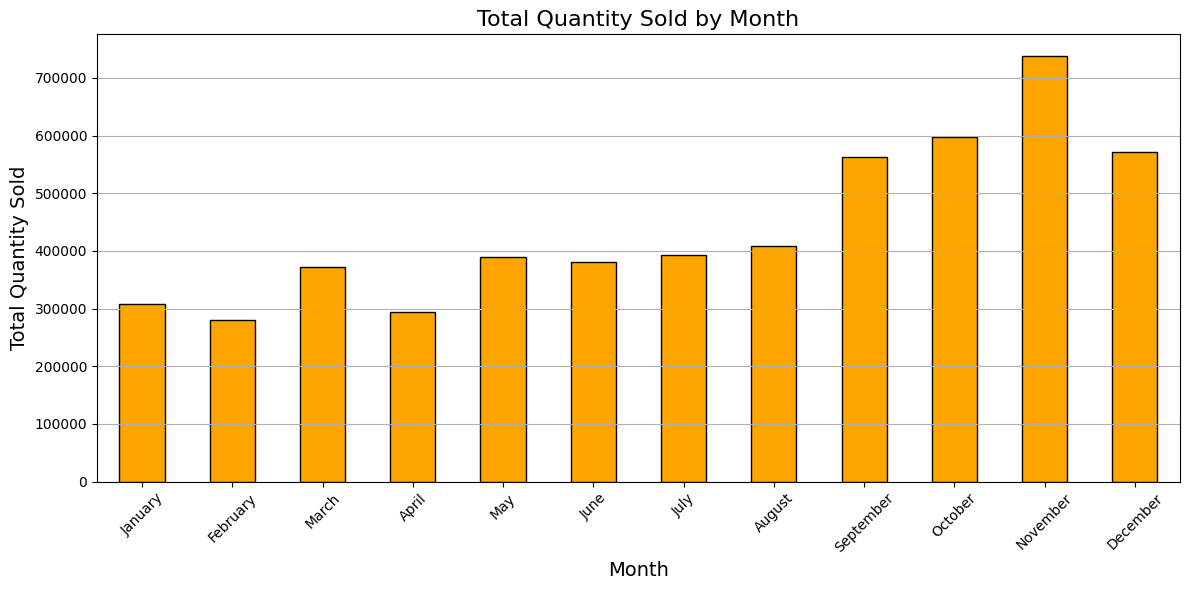

In [19]:
data['Month'] = data['InvoiceDate'].dt.month_name()
monthly_sales = data.groupby('Month')['Quantity'].sum()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(months_order)

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Total Quantity Sold by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Quantity Sold', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


📌 Top 10 Products Sold in October, November, December:
Description
RABBIT NIGHT LIGHT                    25452
POPCORN HOLDER                        24210
WORLD WAR 2 GLIDERS ASSTD DESIGNS     19205
PAPER CHAIN KIT 50'S CHRISTMAS        15579
JUMBO BAG RED RETROSPOT               13824
ASSORTED COLOUR BIRD ORNAMENT         11632
WHITE HANGING HEART T-LIGHT HOLDER    10751
RED  HARMONICA IN BOX                 10269
60 CAKE CASES VINTAGE CHRISTMAS       10193
DISCO BALL CHRISTMAS DECORATION       10051
Name: Quantity, dtype: int64


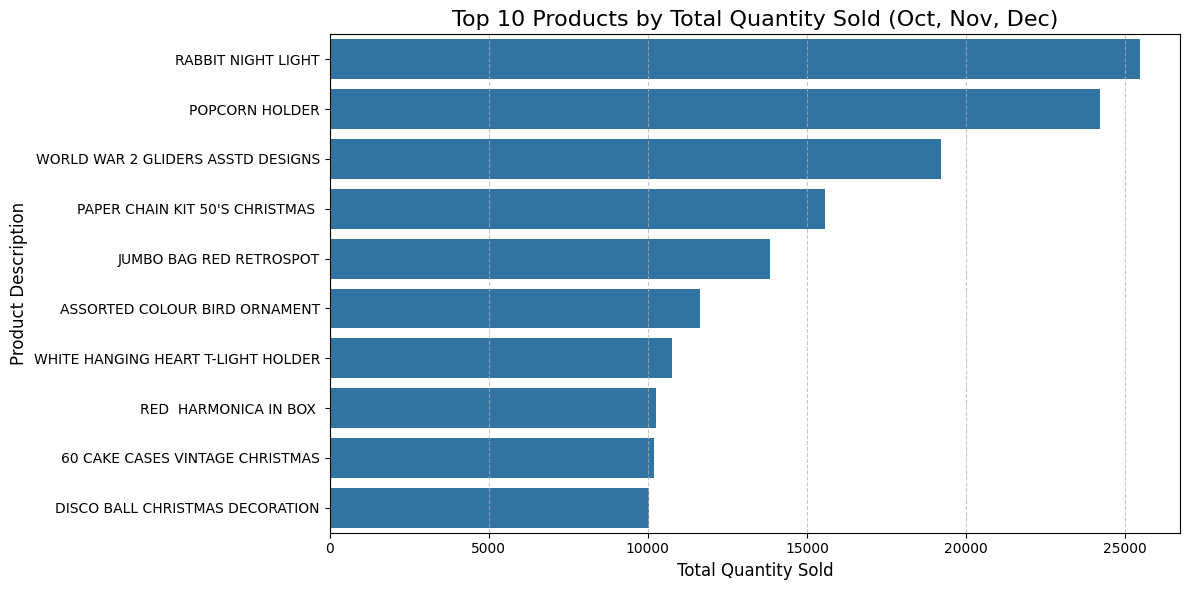

In [20]:
# تأكد ان Month موجود
data['Month'] = data['InvoiceDate'].dt.month_name()
filtered_month_data = data[data['Month'].isin(['October', 'November', 'December'])]

# حساب الكمية المباعة
product_quantity_by_month = filtered_month_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

# عرض أعلى 10 منتجات
print("\n📌 Top 10 Products Sold in October, November, December:")
print(product_quantity_by_month.head(10))

# رسم البار شارت
plt.figure(figsize=(12, 6))
sns.barplot(
    x=product_quantity_by_month.head(10).values,
    y=product_quantity_by_month.head(10).index,
    # color='#3498db'  
)
plt.title('Top 10 Products by Total Quantity Sold (Oct, Nov, Dec)', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




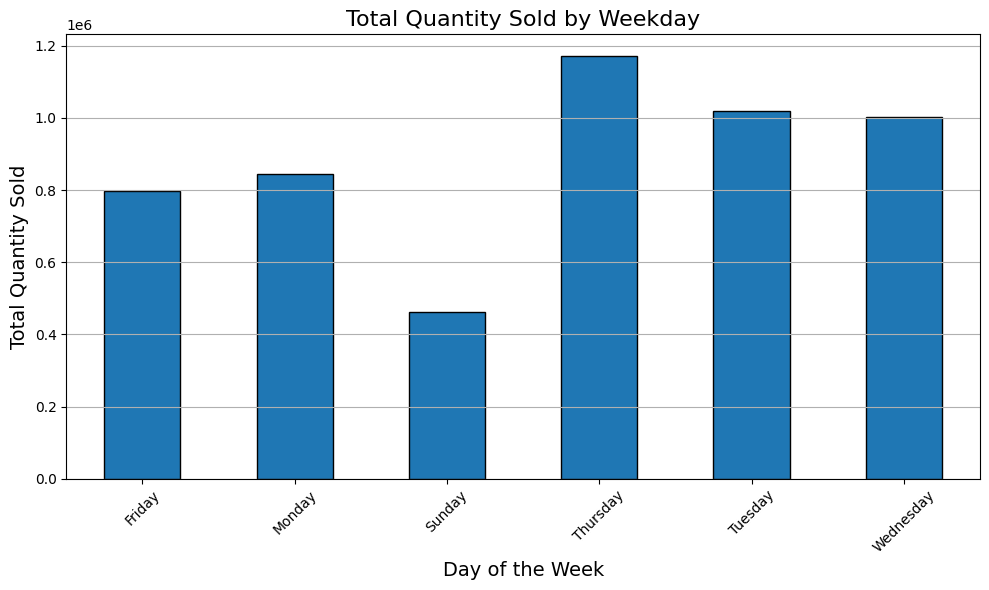

In [21]:
data['Weekday'] = data['InvoiceDate'].dt.day_name()
weekday_sales = data.groupby('Weekday')['Quantity'].sum()
plt.figure(figsize=(10, 6))
weekday_sales.plot(kind='bar', edgecolor='black')
plt.title('Total Quantity Sold by Weekday', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Total Quantity Sold', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


📌 Top 10 Products Sold on Tuesdays and Thursdays:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     24923
JUMBO BAG RED RETROSPOT               20252
WHITE HANGING HEART T-LIGHT HOLDER    18230
ASSORTED COLOUR BIRD ORNAMENT         17077
PACK OF 72 RETROSPOT CAKE CASES       14733
POPCORN HOLDER                        13514
PACK OF 12 LONDON TISSUES             13249
MINI PAINT SET VINTAGE                13066
RABBIT NIGHT LIGHT                    12845
ASSORTED COLOURS SILK FAN             11861
Name: Quantity, dtype: int64


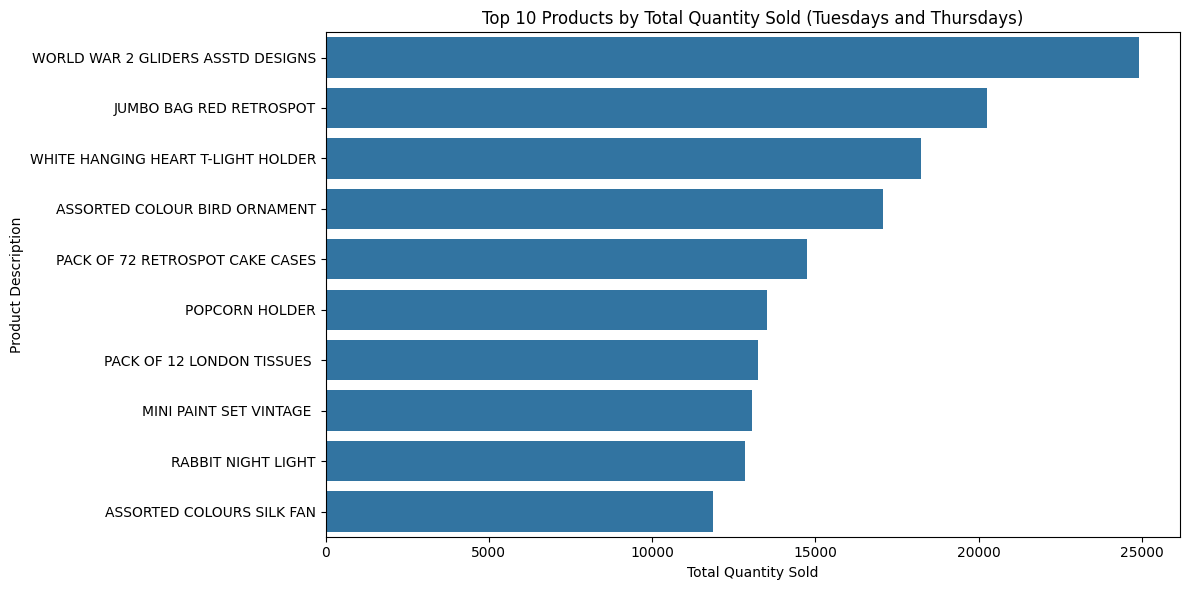

In [25]:
# تصفية البيانات حسب أيام التلات والخميس
data['Weekday'] = data['InvoiceDate'].dt.day_name()
filtered_weekday_data = data[data['Weekday'].isin(['Tuesday', 'Thursday'])]

# حساب الكمية المباعة حسب المنتج في الأيام المحددة
product_quantity_by_weekday = filtered_weekday_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

# عرض أعلى 10 منتجات حسب الكمية في الأيام المحددة
print("\n📌 Top 10 Products Sold on Tuesdays and Thursdays:")
print(product_quantity_by_weekday.head(10))

# رسم بار شارت
plt.figure(figsize=(12, 6))
sns.barplot(x=product_quantity_by_weekday.head(10).values, y=product_quantity_by_weekday.head(10).index)
plt.title('Top 10 Products by Total Quantity Sold (Tuesdays and Thursdays)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()


📌 Top 10 Best-Selling Products (Sales Data Only):
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


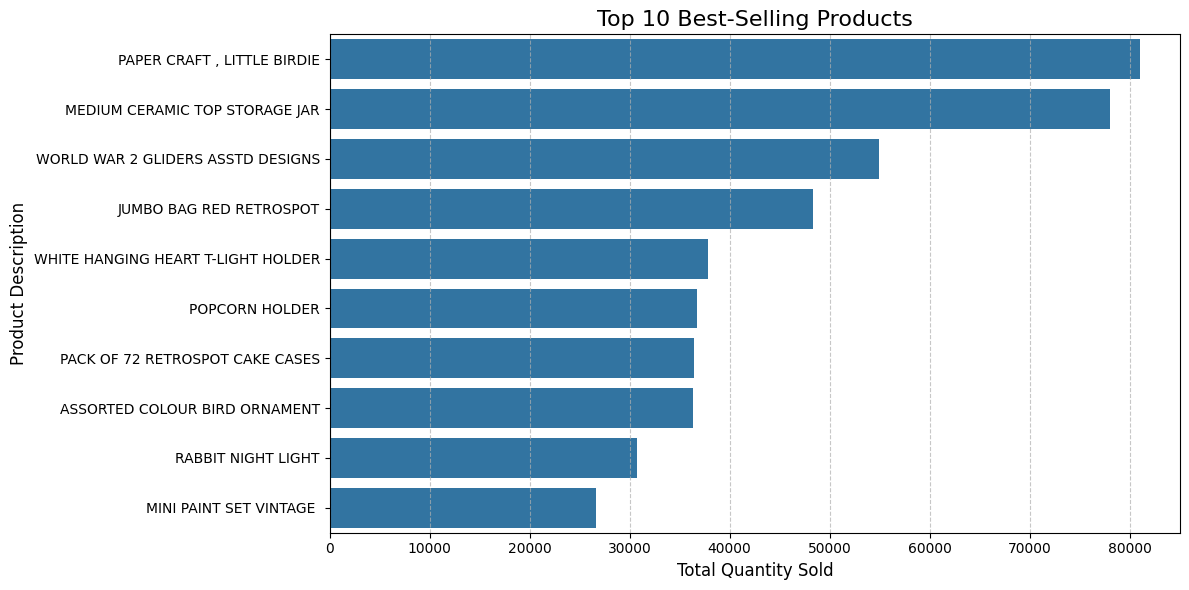

In [23]:

# حساب إجمالي الكمية لكل منتج من بيانات المبيعات
top_products_sales = sales_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

# عرض أعلى 10 منتجات
print("\n📌 Top 10 Best-Selling Products (Sales Data Only):")
print(top_products_sales.head(10))

# رسم البار شارت
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_products_sales.head(10).values,
    y=top_products_sales.head(10).index,
    # color='#2ecc71'  # لون أخضر ثابت وواضح
)
plt.title('Top 10 Best-Selling Products', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


📌 Top 10 Most Returned Products (Returns Data Only):
Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Manual                                  4066
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
WHITE HANGING HEART T-LIGHT HOLDER      2578
GIN + TONIC DIET METAL SIGN             2030
HERB MARKER BASIL                       1527
FELTCRAFT DOLL MOLLY                    1447
TEA TIME PARTY BUNTING                  1424
Name: Quantity, dtype: int64


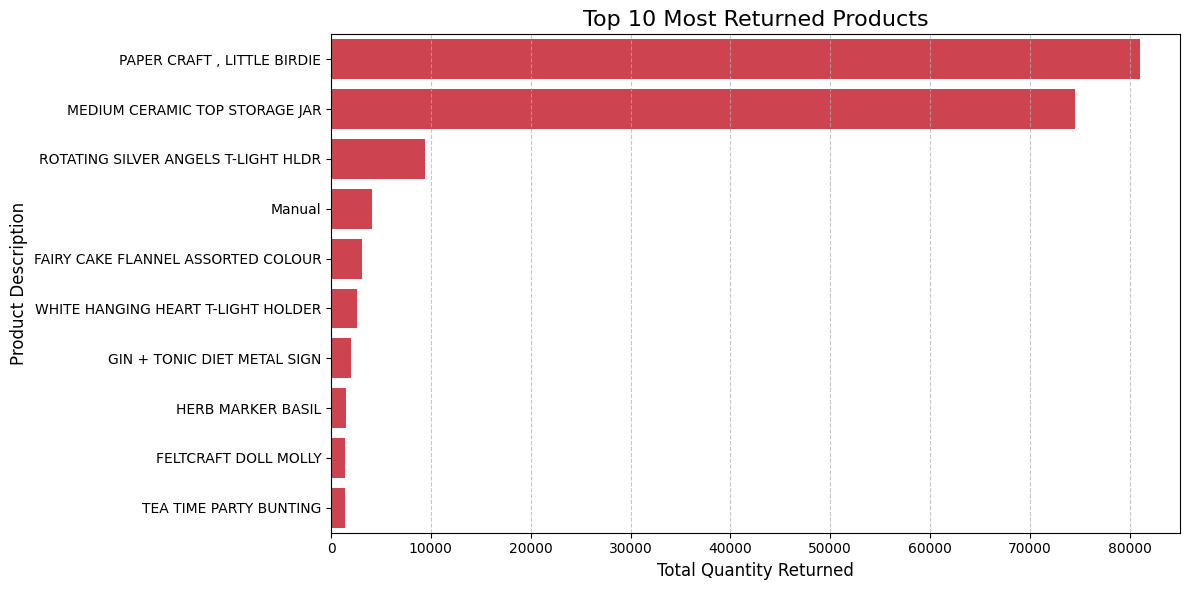

In [24]:

# حساب إجمالي الكمية لكل منتج من المرتجعات
top_products_returns = returns_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

# عرض أعلى 10 منتجات مرتجعة
print("\n📌 Top 10 Most Returned Products (Returns Data Only):")
print(top_products_returns.head(10))

# رسم البار شارت
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_products_returns.head(10).values,
    y=top_products_returns.head(10).index,
    color='#e42c3c'  # لون أحمر ثابت وواضح (بيرمز للمرتجعات أو المشكلات)
)
plt.title('Top 10 Most Returned Products', fontsize=16)
plt.xlabel('Total Quantity Returned', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()